# Packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

trigger_create_cross_section = True

# Model Parameters

In [5]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Plutonite dip angle
plutonite_dip_angle = 70 # 70

# Importing Plutonic Model

In [ ]:
# --- Load full model ---
with open("geomodel.pkl", "rb") as f:
    plutonite_geo_model = pickle.load(f)

# Forward Modelling Gravity

Setting Measurement Grid and Determine which Voxels to use

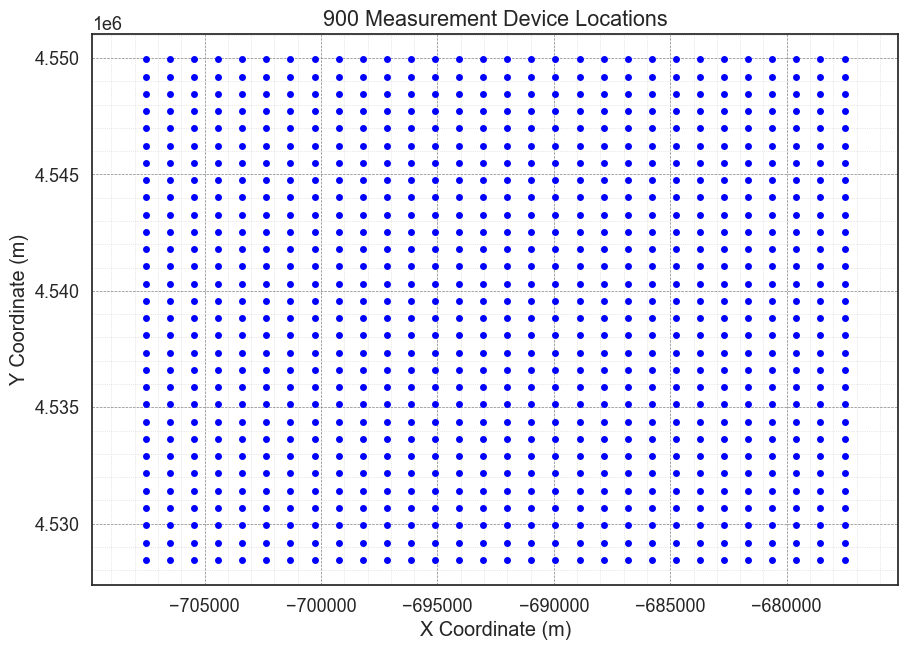

Active grids: GridTypes.NONE|CENTERED|TOPOGRAPHY|DENSE


In [8]:
# Creating grid of measurement devices within the extent
grav_res = 30
X = np.linspace(min_x, max_x, grav_res)
Y = np.linspace(min_y, max_y, grav_res)
Z = max_z
xyz = np.meshgrid(X, Y, Z)
xy_ravel = np.vstack(list(map(np.ravel, xyz))).T

# Plot the measurement device locations
plt.plot(xy_ravel[:,0], xy_ravel[:,1], 'o', color='blue', markersize=5)
plt.grid(which='major', color='grey', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', color='lightgrey', linestyle=':', linewidth=0.5)
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')
plt.title(f'{len(xy_ravel)} Measurement Device Locations')
plt.axis('equal')
plt.show()


# Creating centred grids around the measurements devices
gp.set_centered_grid(
    grid=plutonite_geo_model.grid,
    centers=xy_ravel,
    resolution=np.array([5, 5, 10]),   # the number of voxels we will create in x,y,z directions
    radius=np.array([1000, 1000, 1000])  # the distance of the 3D sphere in which we create voxels
)

plutonite_geo_model.grid.centered_grid.kernel_grid_centers;

Gravity Gradient

In [9]:
# Calculate the gravity gradient
gravity_gradient = gp.calculate_gravity_gradient(plutonite_geo_model.grid.centered_grid)

# Assign densities
plutonite_geo_model.geophysics_input = gp.data.GeophysicsInput(
    tz=gravity_gradient,
    densities=np.array([2, 3]),
)

# Calculate forward modelling gravity response
plutonite_geo_model.interpolation_options.mesh_extraction = False
sol = gp.compute_model(
    gempy_model=plutonite_geo_model,
    engine_config=gp.data.GemPyEngineConfig(
        backend=gp.data.AvailableBackends.numpy,
        dtype='float32'
    )
)

grav = sol.gravity

# 5 min for resolution=np.array([5, 5, 10]), radius=np.array([1000, 1000, 1000])
# 20 min for resolution=np.array([10, 10, 15]), radius=np.array([1000, 1000, 1000])

Setting Backend To: AvailableBackends.numpy
Chunking done: 700 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Gravity Response

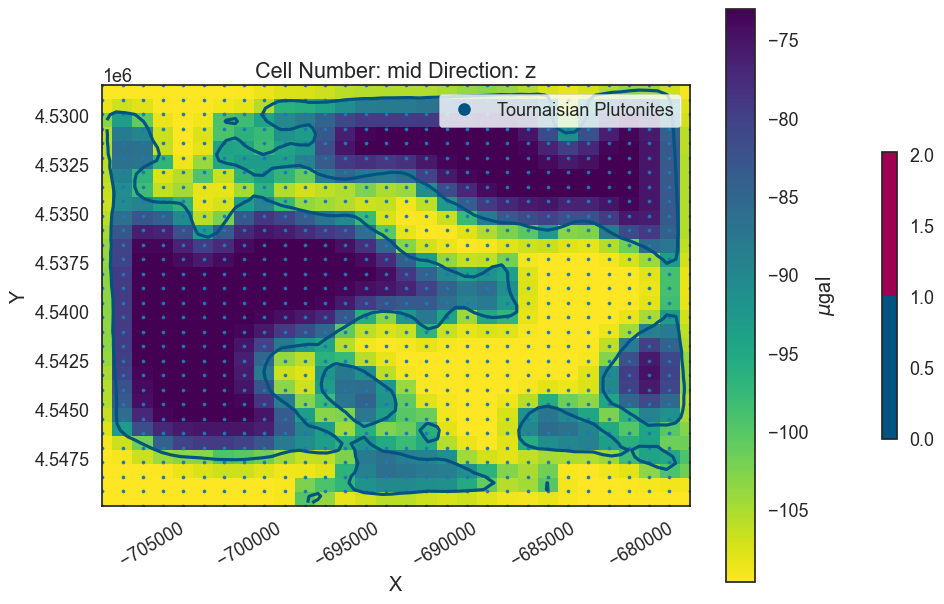

In [10]:
# Gravity response plot
gpv.plot_2d(plutonite_geo_model, direction=['z'], height=7, show_results=True, show_data=False, show=False)
plt.scatter(xy_ravel[:, 0], xy_ravel[:, 1], s=5)
plt.imshow(sol.gravity.reshape(grav_res, grav_res),
           extent=(xy_ravel[:, 0].min() + (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 0].max() - (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 1].min() + (xy_ravel[0, 1] - xy_ravel[10, 1]) / 2,
                   xy_ravel[:, 1].max() - (xy_ravel[0, 1] - xy_ravel[10, 1]) / 2),
           cmap='viridis_r', origin='upper')
cbar = plt.colorbar()
cbar.set_label(r'$\mu$gal')
plt.show()

# Misfit Calculation with QGIS Gravity Data

Set up Measurement Grid and set Geophysical Data

In [11]:
# Importing cleaned gravity data
gravity_data = gpd.read_file(data_dir + r"\cleaned_gravity_data.geojson")


# Create measurement points at gravity data locations
gravity_measurement_points = np.column_stack([
    gravity_data.geometry.x.values,
    gravity_data.geometry.y.values,
    np.full(len(gravity_data), max_z)  # Set Z to surface elevation
])

# Set up centered grid for gravity calculation at observed locations
gp.set_centered_grid(
    grid=plutonite_geo_model.grid,
    centers=gravity_measurement_points,
    resolution=np.array([5, 5, 10]),
    radius=np.array([1000, 1000, 1000])
)

# Calculate gravity gradient for new measurement points
gravity_gradient_obs = gp.calculate_gravity_gradient(plutonite_geo_model.grid.centered_grid)

# Update geophysics input
plutonite_geo_model.geophysics_input = gp.data.GeophysicsInput(
    tz=gravity_gradient_obs,
    densities=np.array([1, 2]),
)

Active grids: GridTypes.NONE|CENTERED|TOPOGRAPHY|DENSE


Do the forward calculation

In [12]:
# Compute forward model at observation points
plutonite_geo_model.interpolation_options.mesh_extraction = False
sol_obs = gp.compute_model(
    gempy_model=plutonite_geo_model,
    engine_config=gp.data.GemPyEngineConfig(
        backend=gp.data.AvailableBackends.numpy,
        dtype='float32'
    )
)

# Get predicted gravity values
predicted_gravity = -sol_obs.gravity  # In mGal and flipping the sign why were gravity values negative in the first place???
observed_gravity = gravity_data['VALU_BOU267'].values  # In mGal

# Calculate misfit statistics
residuals = predicted_gravity - observed_gravity
rms_misfit = np.sqrt(np.mean(residuals**2))
mean_misfit = np.mean(residuals)
std_misfit = np.std(residuals)

Setting Backend To: AvailableBackends.numpy
Chunking done: 466 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Visualise the misfit

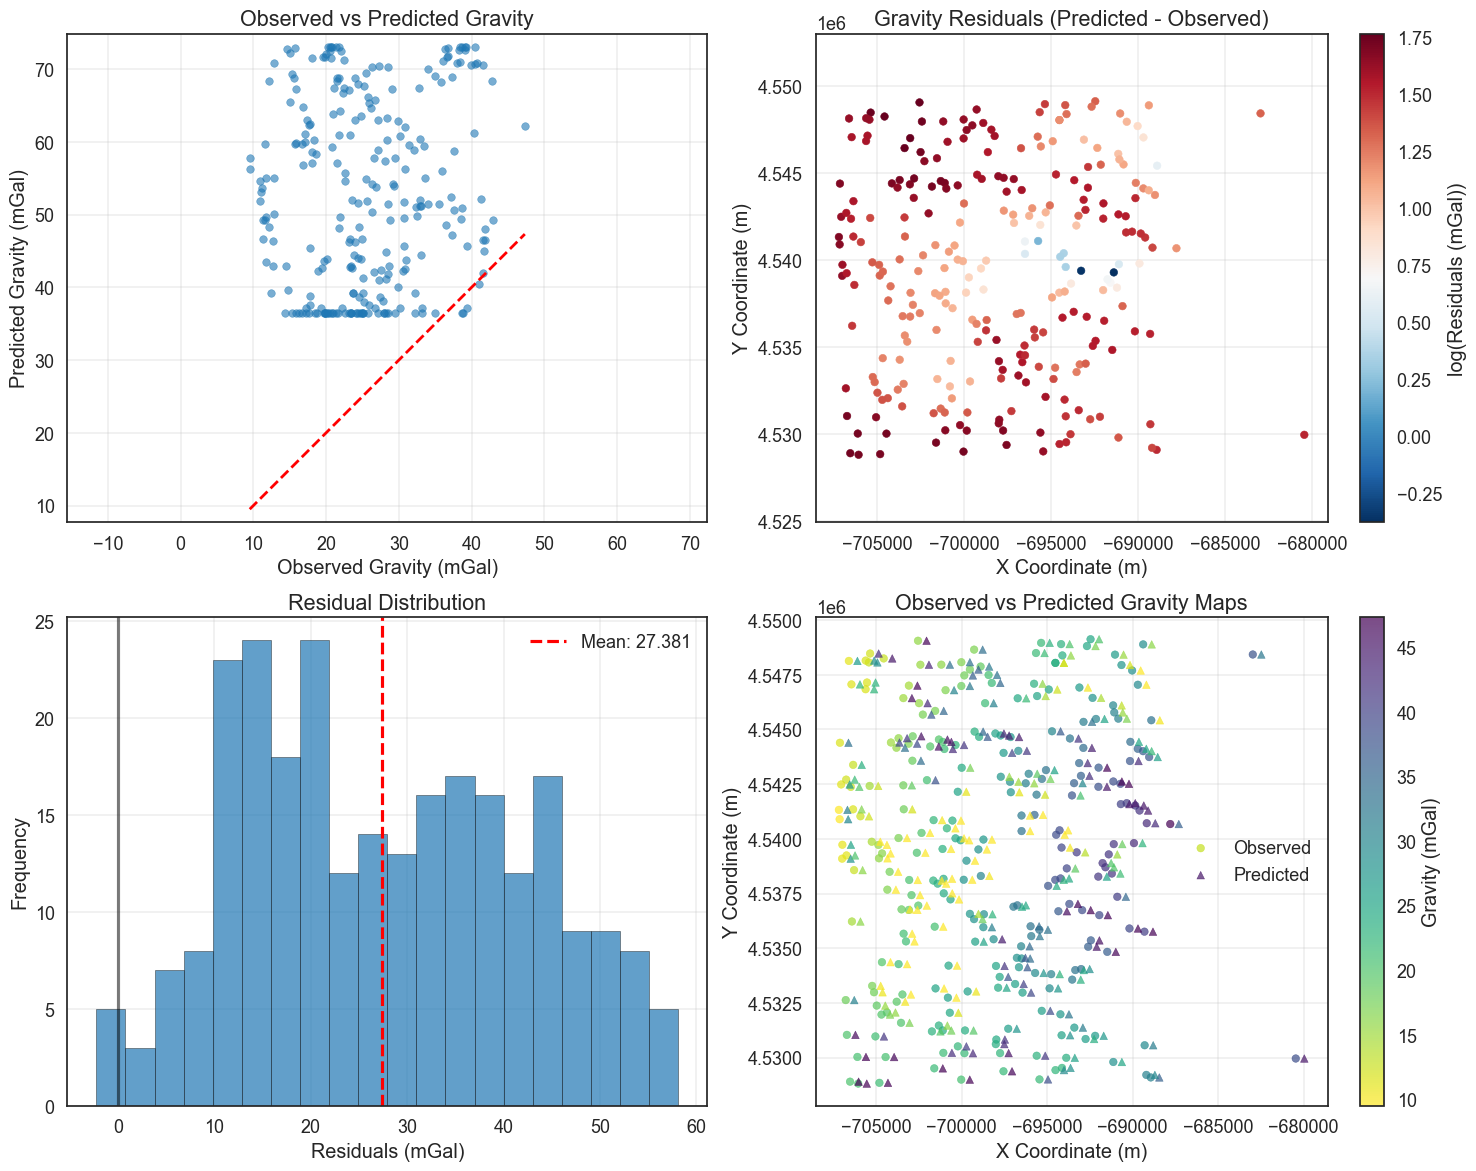

Gravity Misfit Analysis:
  RMS Misfit: 31.009 mGal
  Mean Misfit: 27.381 mGal
  Std Misfit: 14.554 mGal
  Min Residual: -2.243 mGal
  Max Residual: 58.106 mGal


In [13]:
# Create comparison plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Observed vs Predicted scatter
ax1.scatter(observed_gravity, predicted_gravity, alpha=0.6, s=30)
ax1.plot([observed_gravity.min(), observed_gravity.max()], 
         [observed_gravity.min(), observed_gravity.max()], 'r--', lw=2)
ax1.set_xlabel('Observed Gravity (mGal)')
ax1.set_ylabel('Predicted Gravity (mGal)')
ax1.set_title('Observed vs Predicted Gravity')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot 2: Residuals map
scatter = ax2.scatter(gravity_data.geometry.x, gravity_data.geometry.y, 
                     c=np.log10(np.abs(residuals)), cmap='RdBu_r', s=30)
plt.colorbar(scatter, ax=ax2, label='log(Residuals (mGal))')
ax2.set_xlabel('X Coordinate (m)')
ax2.set_ylabel('Y Coordinate (m)')
ax2.set_title('Gravity Residuals (Predicted - Observed)')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# Plot 3: Residual histogram
ax3.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
ax3.axvline(mean_misfit, color='red', linestyle='--', label=f'Mean: {mean_misfit:.3f}')
ax3.axvline(0, color='black', linestyle='-', alpha=0.5)
ax3.set_xlabel('Residuals (mGal)')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Observed and predicted gravity maps side by side
im1 = ax4.scatter(gravity_data.geometry.x, gravity_data.geometry.y, 
                 c=observed_gravity, cmap='viridis_r', s=30, alpha=0.7, 
                 label='Observed')
ax4.scatter(gravity_data.geometry.x + 500, gravity_data.geometry.y, 
           c=predicted_gravity, cmap='viridis_r', s=30, alpha=0.7, 
           marker='^', label='Predicted')
plt.colorbar(im1, ax=ax4, label='Gravity (mGal)')
ax4.set_xlabel('X Coordinate (m)')
ax4.set_ylabel('Y Coordinate (m)')
ax4.set_title('Observed vs Predicted Gravity Maps')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Gravity Misfit Analysis:")
print(f"  RMS Misfit: {rms_misfit:.3f} mGal")
print(f"  Mean Misfit: {mean_misfit:.3f} mGal")
print(f"  Std Misfit: {std_misfit:.3f} mGal")
print(f"  Min Residual: {np.min(residuals):.3f} mGal")
print(f"  Max Residual: {np.max(residuals):.3f} mGal")